# Numerical Integration

Consider a function $f(x)$ and we want the value of the integral $I$:

$$ I = \int_{a}^{b} f(x) dx $$

There are two cases where we need to do integrals:
1. We are given an analytic function $f(x)$ and are free to evaluate it wherever we wish to compute the integral in a domain $[a,b]$.
2. We are given the value of $f(x_i)$ at $N$ points (possibly equally spaced) in $[a,b]$ and want to use them to construct the integral over the domain.

In practice, we can treat case 1 and case 2 with the same methods by treating the data we have at discrete points. 

## Composite Integration

Calculus tells us that the integral is the sum of the area under the curve. If we **discretize**, i.e. break up the domain into chunks, we can treat the integral as the sum of all the individual areas of the component chunks, where the sum of the individual areas of the chunks is the numerical calculation of the integral such that $$I \approx \sum_{i=0}^{n} I_i$$

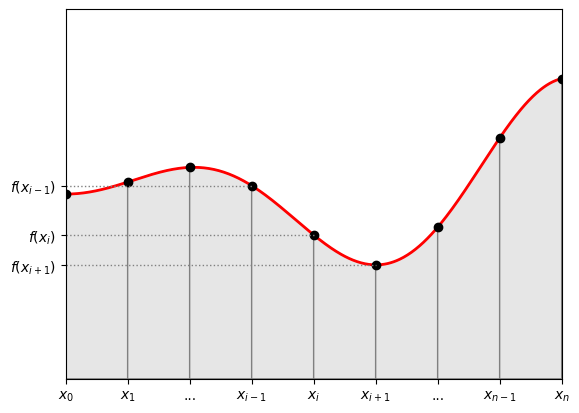



### Rectangle Rule
If we assume each chunk can be approximated by a rectangle of width $\Delta x = x_{i+1} - x_i$ and height $f_i = f(x_i)$ or $f_{i+1} = f(x_{i+1})$, this is the familiar rectangle rule (otherwise known as the Reimman Sum). 
Then, the choice of at which side of the rectangle to evaluate it's height, determines whether it is a left-handed of right-handed Reimman sum. 
If it is evaluated at the midpoint $f_{i+1/2} = f(\frac{x_{i+1} + x_i}{2})$, then this is the familiar **midpoint rule**.

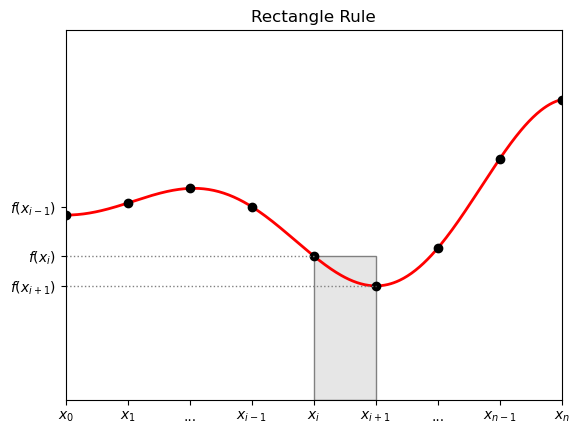


+ Left: $I_i = \Delta x f_i $

+ Right: $I_i = \Delta x  f_{i+1} $

+ Midpoint: $I_i = \Delta x f_{i+1/2}$

```{embed} #ex_4-1
```

```{embed} #sol_4-1
```

### Trapezoidal Rule
You can see that depending on the behavior of $f(x)$ on sub-intervals between $x_i$ and $x_{i+1}$, the rectangle can be an over- or under-estimate of the true area under the curve.
If we *linearly interpolate* between $f_{i}$ and $f_{i+1}$, then we can model the area of the chunk as the area of a trapezoid with bases $f_i$ and $f_{i+1}$ and height $\Delta x$ and recover the Trapezoidal rule. 

+ $I_i = \frac{\Delta x}{2} ( f_i + f_{i+1} )$

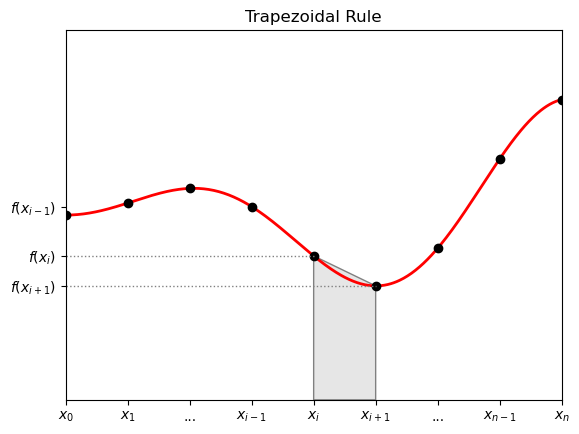

Equivalently, we can also define the stencil:
+ $I_i = \frac{\Delta x}{2} ( f_{i-1} + f_{i} )$


### Simpson's Rule
Since the trapezoidal rule is a linear interpolation, in principle, we could interpolate the function between any set of points as a higher-order polynomial for greater accuracy.  
Simpson's rule uses information at three points: $x_{i-1}, x_{i}, x_{i+1}$ to come up with a second-order polynomial to mimic the behavior of $f$ between grid points.

$$g(x) = A(x-x_0)^2 + B(x-x_0) + C$$

Solving for the three unknowns at three points:

$$ A = \frac{f_{i-1} - 2f_{i} + f_{i+1}}{2\Delta x^2}$$
$$ B = - \frac{f_{i+1} - 4f_{i} + 3 f_{i-1}}{2\Delta x}$$
$$ C = f_{i-1}$$

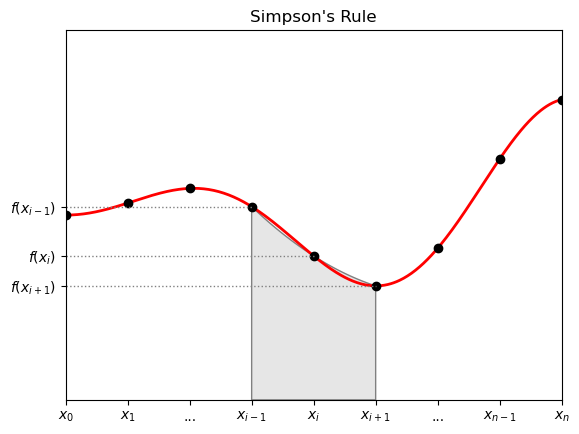

We end up with:

+ $I_i = \frac{\Delta x}{3} ( f_{i-1} + 4 f_i + f_{i+1} )$

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_4-1
```

### Integrating on an infinite domain

If we want to numerically approximate an integral with infinity at one of the bounds, you might notice that we can not keep integrating infinite chunks together forever. 

Consider the integral:
$$ I = \int_0^{\infty} f(x) dx $$

A change of variables will allows us to change the bounds of the integral. For example:

$$ z = \frac{x}{1+x}  \Longleftrightarrow  x =\frac{z}{1-z}$$

Then we can integrate in terms of $dz$:
$$ dx = \frac{dz}{(1-z)^2}$$

such that:

$$ I = \int_0^1 = f\left( \frac{z}{1-z}\right) \frac{dz}{(1-z)^2}$$

You can see examples for other infinite domains [here](https://en.wikipedia.org/wiki/Numerical_integration#Integrals_over_infinite_intervals)


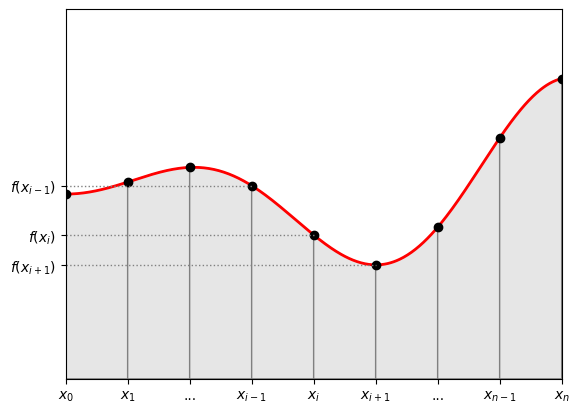

In [124]:
f,ax = plt.subplots()

x_a = np.linspace(0,2.5,500)
x_n = np.linspace(0,2.5,9)

def func(x):
    #return x ** 3 + (x - 0.5)**2 - x**4 + 0.5*x + 0.1*np.sin(x*10)
    return 1 + x/4 * np.sin(np.pi*x)

def add_shape(a,b,ax,shape='rect'):
    #ix = np.linspace(a, b)
    #iy = func(ix)
    if shape == 'rect':
        verts = [(a, 0),(a,func(a)),(b,func(a)),(b, 0)]
    if shape == 'trap':
        ix = np.linspace(a,b)
        m = (func(b) - func(a))/(b-a)
        c = func(a) - m*a
        iy = m * ix + c
        verts = [(a, 0),*zip(ix,iy),(b, 0)]
    if shape == 'simp':
        ix = np.linspace(a,b)
        dx = (b-a)/2.
        f0 = func(a)
        f2 = func(b)
        f1 = func((a+b)/2.)
        x0 = a
        A = (f0 - 2*f1 + f2)/(2 * (dx)**2)
        B = -(f2 - 4*f1 + 3*f0)/(2*dx)
        C = f0
        iy = A*(ix-x0)**2 + B*(ix-x0) + C
        verts = [(a, 0),*zip(ix,iy),(b, 0)]
    else:
        ix = np.linspace(a,b)
        iy = func(ix)
        verts = [(a, 0),*zip(ix,iy),(b, 0)]
    poly = Polygon(verts, facecolor='0.9', edgecolor='0.5')
    ax.add_patch(poly)

f_a = func(x_a)
f_n = func(x_n)
ax.set_ylim(0,2)
ax.set_xlim(0,1)

ax.plot(x_a,f_a,lw=2,color='r')
ax.plot(x_n,f_n,linestyle="",marker='o',color='k')

#add_shape(x_n[4],x_n[5],ax,shape='rect')
for i in range(len(x_n)-1):
    add_shape(x_n[i],x_n[i+1],ax,shape='other')

def label(x):
    n = len(x)
    labels = []
    for i in range(n):
        if i < 3:
            if i!= 2:
                str_val = str(i)
                labels.append('$x_{}$'.format(str_val))
            else:
                labels.append("...")
        elif i == n-3:
                labels.append("...")
        elif i > n - 3:
            if i != n-1:
                str_val = "{n-" + str(n-i-1) + "}"
            else:
                str_val = "{n}"
            labels.append('$x_{}$'.format(str_val))
        else:
            i_mid = n//2
            i_val = i - i_mid 
            if i_val < 0:
                i_val = str(i_val)
            elif i_val > 0:
                i_val = "+" + str(i_val)
            else:
                i_val = ""
            str_val = "{i" + i_val + "}"
            labels.append('$x_{}$'.format(str_val))
    return labels

ax.set_xticks(x_n)
ax.set_xticklabels(label(x_n))
ax.set_yticks([func(x_n[3]),func(x_n[4]),func(x_n[5])])
ax.set_yticklabels(["$f(x_{i-1})$", "$f(x_{i})$", "$f(x_{i+1})$"])

ax.plot(x_n[:6],np.ones_like(x_n[:6])*func(x_n[5]),color='gray',lw=1,ls='dotted')
ax.plot(x_n[:5],np.ones_like(x_n[:5])*func(x_n[4]),color='gray',lw=1,ls='dotted')
ax.plot(x_n[:4],np.ones_like(x_n[:4])*func(x_n[3]),color='gray',lw=1,ls='dotted')
#ax.set_title("Rectangle Rule")

## Integration Error

Like in the definition of a numerical derivative [last week](./3a_accuracy.ipynb), we can use also use Taylor Series expansions of a two point stencil to represent a numerical integral (see: Newman Section 5.2). 

For example, considering iteration on $f_{i-1}$ and $f_i$, for $h = x_i - x_{i-1}$, the composite integral across the entire domain [a,b]can be written as (Newman Eq. 5.19):

$$ \int_a^b f(x)dx = \frac{1}{2} h \sum_{i=1}^{n} [f_{i-1} + f_{i}] + \frac{1}{12}h^2 [f^\prime(a) - f^\prime(b)] + \mathcal{O}(h^4)$$

Here the first term is our expression for the trapezoidal rule, thus the error between our exact expression and the numerical integral is governed by the truncation (or approximation) error. 

The expression for this error is called the *Euler-Maclaurin Error*.

Thus, for the **trapezoidal rule** , the Euler-Maclaurin Error is:

$$\epsilon = \frac{1}{12}h^2 [f^\prime(a) - f^\prime(b)]$$

We can see that since the order of the error is $h^2$, the trapezoidal scheme is **first-order accurate**.

A similar expression can be derived for **Simpson's rule**:

$$\epsilon = \frac{1}{180} h^4 [f^{\prime\prime}(a) - f^{\prime\prime}(b)]$$

From this, we can see that Simpson's rule is a **third-order** scheme.

### Practical Estimation of Errors
The Euler-Maclaurin error formulas depend on the knowledge of the continuous form of the function $f(x)$. However, in practice, we often don't know the functional form of $f(x)$ and only have a discrete data set to go off of. 
We can write the numerical integral, $I_n$, as the sum of the analytic value of the integral $I$ and the leading-error term defined by the Euler-Maclaurin Error:
$$I_k = I - \epsilon_k$$

So, for the trapezoid rule, we would have:
$$I_k = I + \frac{1}{12}h_k^2 [f^\prime(a) - f^\prime(b)]$$

If we consider performing the numerical integral twice, where $I_1$ is computed with $h= h_1$ and $I_2$ with $h=h_2=h_1/2$, we can show that the difference between the two will yield a value three times the error for $I_2$:
$$|I_2 - I_1| = \frac{1}{12}[f^\prime(a) - f^\prime(b)](h_2^2 - h_1^2) = \frac{1}{12}[f^\prime(a) - f^\prime(b)](3 h_2^2) = 3 \epsilon_2$$ 

Thus, for our two methods, we can use estimate the error by comparing numerical integrals performed before and after *refining* our value of h:
+ Trapezoid:  $\epsilon_2 = \frac{1}{3} |I_2 - I_1|$
+ Simpson's: $\epsilon_2 = \frac{1}{15} |I_2 - I_1|$


<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_4-2
```

## Adaptive and Higher Order Schemes

So we could, in principle, just choose a large enough value of $N$ until we reach our desired accuracy by doubling $N$ until we reach a low enough error.

```{embed} ex_4-2
```

But what if we used our previous iteration to improve our error?

Consider a general form of our previous expression for an integral using the trapezoidal rule:
$$ I = I_k + \epsilon_k + \mathcal{O}(h^4)$$

where:
$$\epsilon_k = (I_k - I_{k-1})/3$$

If you look at the expression, you might be able to see that actually if we know the value of the error, we could in principle "correct" our expression by using the numerical integral previously computed on a coarser grid:

$$I = I_k + (I_k - I_{k-1})/3 + \mathcal{O}(h^4)$$

If you evaluate the numerical integral using the first two terms, you can see that you'll now end up with a **third-order** accurate scheme using the trapezoidal method. 

This is known as a **Richardson Extrapolation**. 

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_4-3
```

### Romberg Integration




By applying successive Richardson Extrapolations iteratively, we can define what is known as a Romberg Integration Scheme.  
In Romberg notation, the next iteration is given by:
$$R_{i,m+1} = R_{i,m} + \frac{1}{4^m - 1}( R_{i,m} - R_{i-1,m})$$
where $i$ is the number of adaptive steps and $m$ is the order of the correction. 

For example, our first step is our first integral:
1. $I_1 = R_{1,1}$
2. $I_2 = R_{2,1}$

Then we apply a correction:

3. $I_2 \rightarrow R_{2,2} = R_{2,1} + \frac{1}{3}( R_{2,1} - R_{1,1})$

Then we integrate again:

4. $I_3 = R_{3,1}$

Then we apply an iterative correction:

5. $I_3  \rightarrow R_{3,2} = R_{3,1} + \frac{1}{3}( R_{3,1} - R_{2,1})$
6. $I_3  \rightarrow R_{3,3} = R_{3,2} + \frac{1}{15}( R_{3,2} - R_{2,2})$

which lets us use the information from previous integrations to keep correcting.

### Gaussian Quadrature

```{tip} Quadrature Rules
It turns out that if we can write out an expression for an integral of a function $f(x)$ as the sum of the function evaluated across a set of discrete points $x_i$ with some weight $w_i$ at each point, we have what is called a **Quadrature Rule**

$$I = \int_{a}^{b} f(x) dx \approx \sum_{i=1}^n w_i f(x_i)$$

So, pretty much any numerical integral can be generalized in terms of their quadrature rule expression.

Rectangle, Trapezoid, and Simpson's Rule methods, when evaluated on evenly spaced points, fall under the classification of [Newton-Cotes quadrature rules](https://en.wikipedia.org/wiki/Newton%E2%80%93Cotes_formulas).
```

The weights used in the quadrature rules depend on the order of the polynomial to interpolate between points:
+ 2 points --> 1st order Linear interpolation (Trapezoid rule)
+ 3 points --> 2nd order Quadratic interpolation (Simpson's rule)
+ N points --> (N-1)th order polynomial ?? (Exact only if $f(x)$ is an (N-1)th degree polynomial)

Gaussian quadrature is dependent on choosing $x_i$ strategically to find the weights $w_i$ that are best approximation to the integral: polynomial of order $2N-1$






### Ex: Gauss-Legendre Quadrature Procedure
1. Uses [Legendre Polynomials](https://en.wikipedia.org/wiki/Legendre_polynomials) on the interval $[-1,1]$ as the basis. 
    + points $x_i$ sampled at the zeros of the Nth degree Legendre polynomials $P_N(x)$
    + weights $$w_i = \frac{2}{(1-x_i^2)} \left[\frac{dP_N}{dx}(x_i)\right]^{-2}$$
(These are pre-tabulated so you can reuse)

```{note} Legendre Polynomial Basis Function
:class: dropdown
$$ f_N(x) = \sum_{\ell=0}^{N} a_{\ell} P_{\ell}(x)$$
$f_N(x)$ converges to $f(x)$ as $N \rightarrow \infty$ given:
$$a_{\ell} = \frac{2\ell + 1}{2} \int_{-1}^{1} f(x) P_{\ell}(x) \, dx.$$
```


2. Re-scale tabulated points and weights to the domain of interest $[a,b]$:
    + points: $$x^\prime_i = \frac{1}{2}(b-a) x_i + \frac{1}{2}(b+a)$$
    + weights: $$w^\prime_i = \frac{1}{2}(b-a) w_i$$

3. Compute the integral as the weighted sum:
$$\int_a^b f(x) dx \approx \sum_{i=1}^{N} w_i f_i$$

You can see the example usage of [gaussxw.py](../in-class/gaussxw.py) module below, which uses $N=4$ sample points does a pretty good job!


In [ ]:
from gaussxw import gaussxw
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**4 - 2*x + 1

def F(x):
    return 0.2*x**5 - x**2 + x

N = 4
a = 0.0
b = 2.0
I_a = F(b) - F(a)
# calculate the sample points and weights
x, w = gaussxw(N)

# map the sample points and weights to the required domain
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w


# perform the integral
I = 0.0
for k in range(N):
    I += wp[k] * f(xp[k])

print('N =',N, '--> integral =',I, 'error =', abs(I-I_a))

fig,ax = plt.subplots()
ax.plot(xp,wp*f(xp),'ko',label='sample weights')
ax.plot(*zip(*[[x,f(x)] for x in np.linspace(a,b,100)]),color='red',lw=2,label='f(x)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()


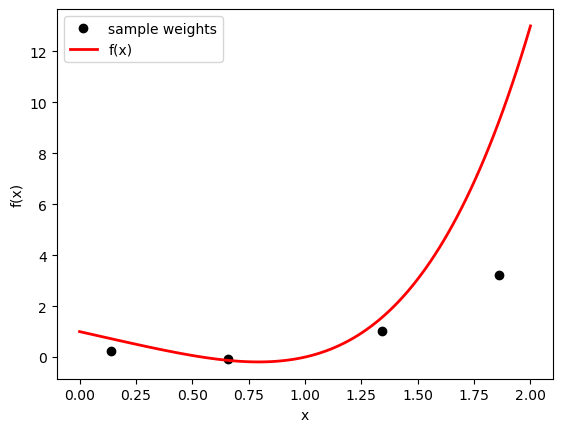

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_4-1
```